# Shaw-style Upside simulation figures

This notebook reproduces the main visual analyses in the attached Shaw/Skinner-style figures for the Upside simulations in this repository. It uses `mdtraj`, `mdtraj_upside`, `numpy`, and `matplotlib`.

The notebook is intentionally data-driven: it discovers `simulations/<protein>/outputs/remd/*.up`, prefers complete `run.N.up` replica sets, loads trajectories with `mdtraj_upside.load_upside_traj`, computes structural observables with MDTraj, and renders figures in the same panel grammar as the screenshots: time traces, folded/DSE state parsing, H-bond/contact maps, residue propensities, secondary structure, and melting-style summaries.

Before running, install the analysis packages in the Jupyter kernel environment and make the Upside Python utilities visible:

```bash
pip install mdtraj matplotlib numpy pandas tables
export UPSIDE_HOME=/path/to/upside2-md
```

The upstream Upside documentation describes the key loader used here as:

```python
import mdtraj_upside as mu
traj = mu.load_upside_traj('simulation.up')
```

That loader adds amide H, carbonyl O, and CB atoms, which lets MDTraj compute hydrogen bonds, DSSP secondary structure, contacts, RMSD, and radius of gyration from the coarse-grained Upside output.

The final section adds exact Skinner Fig. 1 rendering from the bundled paper PDF plus HDF5-only Rg/frame and swap diagnostics. Those cells execute even when the optional `mdtraj_upside` adapter is not available, using the `.up` position, temperature, replica-index, and swap-counter arrays directly.


## Paper-method alignment

I checked the local Shaw/Robustelli 2018, Skinner/Yu/Sosnick 2014, and Sosnick Upside-HDX paper text before choosing these defaults. The notebook now follows these points:

- Skinner et al. analyze native/total H-bonds, C-alpha RMSD, Rg, and TM score, then define NuG2b `NSEsim` with fixed cutoffs: RMSD below 4 A, native H-bonds above 20, and TM score above 0.6. All other conformations are `DSEsim`.
- This notebook uses the same fixed-state logic. Since no TM-score executable/data product is bundled here, native-contact fraction is used as the TM-like native-similarity surrogate with the same 0.6 cutoff.
- Shaw/Robustelli Fig. 4 uses simulated tempering ladders in Kelvin and system-specific folded/helix observables. The local Upside runs are reduced-temperature REMD, so the notebook reads the stored Upside reduced temperatures and labels them as reduced temperatures until a Kelvin calibration is added.
- The Sosnick Upside-HDX workflow uses T-REMD ensembles, MBAR/free-energy analysis, and two-state fits for calibrated melting curves. This notebook shows raw replica-bin folded fractions and overlays a monotonic two-state fit as the thermodynamic guide; MBAR/demultiplexed thermodynamics is still the next step before publication-grade melting curves.


In [1]:
from __future__ import annotations

import math
import os
import re
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np

os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

try:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
except ImportError as exc:
    raise ImportError('Install matplotlib in this Jupyter environment: pip install matplotlib') from exc

try:
    import mdtraj as md
except ImportError as exc:
    raise ImportError('Install MDTraj in this Jupyter environment: pip install mdtraj') from exc

REPO = Path.cwd()
if not (REPO / 'simulations').exists():
    REPO = Path.cwd().parent
SIM_ROOT = REPO / 'simulations'
PDB_ROOT = REPO / 'pdb'
FIG_ROOT = REPO / 'docs' / 'figures'
FIG_ROOT.mkdir(parents=True, exist_ok=True)

upside_home = os.environ.get('UPSIDE_HOME')
upside_py_candidates = []
if upside_home:
    upside_py_candidates.append(Path(upside_home) / 'py')
upside_py_candidates += [REPO / 'upside2-md' / 'py', REPO / 'util']
for candidate in upside_py_candidates:
    if (candidate / 'mdtraj_upside.py').exists():
        sys.path.insert(0, str(candidate))
        break

try:
    import mdtraj_upside as mu
    HAVE_MDTRAJ_UPSIDE = True
except ImportError:
    mu = None
    HAVE_MDTRAJ_UPSIDE = False
    warnings.warn(
        'Could not import mdtraj_upside. Adapter-dependent structural panels will be skipped; '
        'the exact paper figure and HDF5-only Rg/swap diagnostics will still execute.',
        RuntimeWarning,
    )

mpl.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 11,
    'legend.fontsize': 7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.1,
})

MODEL_COLORS = {
    'native': '#666666',
    'within_1': '#d000d0',
    'within_2': '#f0d000',
    'other': '#00c8c8',
    'helix': '#e41a1c',
    'sheet': '#1f4be3',
    'coil': '#188a34',
    'turn': '#00bcd4',
    'total_hbond': '#ff3030',
    'native_hbond': '#2ee84a',
}

N_REPLICAS = 16
T_LOW = 0.80
T_HIGH = 0.96
REDUCED_TEMPERATURES = np.linspace(np.sqrt(T_LOW), np.sqrt(T_HIGH), N_REPLICAS) ** 2

print(f'Repo: {REPO}')
print(f'Figures will be written to: {FIG_ROOT}')

Very Important: All distances are in nanometers for MDTraj
Repo: \\wsl.localhost\Ubuntu\home\okleinmann\projects\hdx-benchmark-desmond-upside
Figures will be written to: \\wsl.localhost\Ubuntu\home\okleinmann\projects\hdx-benchmark-desmond-upside\docs\figures


In [2]:
@dataclass(frozen=True)
class ReplicaSet:
    protein: str
    label: str
    files: tuple[Path, ...]
    temperatures: np.ndarray

    @property
    def has_complete_tempering_set(self) -> bool:
        return len(self.files) == len(self.temperatures)


def _sort_key(path: Path) -> tuple[int, str]:
    match = re.search(r'(?:run\.|rep)(\d+)\.up$', path.name)
    if match:
        return int(match.group(1)), path.name
    return 10_000, path.name


def _valid_up_file(path: Path) -> bool:
    return path.name.endswith('.up') and 'Zone.Identifier' not in path.name and path.stat().st_size > 1024


def discover_replica_sets(sim_root: Path = SIM_ROOT) -> dict[str, ReplicaSet]:
    replica_sets = {}
    for protein_dir in sorted(p for p in sim_root.iterdir() if p.is_dir()):
        remd_dir = protein_dir / 'outputs' / 'remd'
        if not remd_dir.exists():
            continue
        files = [p for p in remd_dir.iterdir() if _valid_up_file(p)]
        run_files = sorted([p for p in files if re.search(r'\.run\.\d+\.up$', p.name)], key=_sort_key)
        rep_files = sorted([p for p in files if re.search(r'\.rep\d+\.up$', p.name)], key=_sort_key)
        single_files = sorted([p for p in files if p not in run_files and p not in rep_files], key=_sort_key)
        if len(run_files) >= 2:
            selected = tuple(run_files)
            label = 'run.N.up'
        elif len(rep_files) >= 2:
            selected = tuple(rep_files)
            label = 'repXX.up'
        elif single_files:
            selected = tuple(single_files[:1])
            label = 'single .up'
        else:
            continue
        temps = REDUCED_TEMPERATURES[:len(selected)] if len(selected) <= N_REPLICAS else np.arange(len(selected))
        replica_sets[protein_dir.name] = ReplicaSet(protein_dir.name, label, selected, temps)
    return replica_sets


replica_sets = discover_replica_sets()
for name, reps in replica_sets.items():
    print(f'{name:18s} {len(reps.files):2d} files from {reps.label}; first={reps.files[0].name}')

lambda_d14a        16 files from run.N.up; first=lambda_d14a.run.0.up
lambda_repressor   16 files from run.N.up; first=lambda_repressor.run.0.up
nug2b              16 files from run.N.up; first=nug2b.run.0.up
ubiquitin          16 files from run.N.up; first=ubiquitin.run.0.up


In [3]:
def load_upside_file(path: Path, stride: int = 1, add_atoms: bool = True) -> md.Trajectory:
    if mu is None:
        raise ImportError(
            'mdtraj_upside is not available in this kernel. Set UPSIDE_HOME or use the HDF5-only '
            'plotting functions added below.'
        )
    traj = mu.load_upside_traj(str(path), stride=stride, add_atoms=add_atoms)
    if traj.time is None or len(traj.time) != traj.n_frames:
        traj.time = np.arange(traj.n_frames, dtype=float)
    return traj


def upside_output_groups(handle):
    index = 0
    while f'output_previous_{index}' in handle.root:
        yield handle.get_node(f'/output_previous_{index}')
        index += 1
    if 'output' in handle.root:
        yield handle.root.output


def read_upside_output_series(path: Path, dataset: str, stride: int = 1) -> np.ndarray:
    try:
        import tables as tb
    except ImportError as exc:
        raise ImportError('Reading Upside output metadata requires PyTables: pip install tables') from exc
    values = []
    with tb.open_file(path) as handle:
        for group_index, group in enumerate(upside_output_groups(handle)):
            raw = np.asarray(getattr(group, dataset)[:]).squeeze()
            start = 0 if group_index == 0 else 1
            values.append(raw[start::stride])
    return np.concatenate(values) if values else np.array([])


def read_upside_temperatures(path: Path, stride: int = 1) -> np.ndarray:
    return read_upside_output_series(path, 'temperature', stride=stride).astype(float)


def load_native(protein: str) -> md.Trajectory | None:
    pdb = PDB_ROOT / f'{protein}.pdb'
    return md.load(str(pdb)) if pdb.exists() else None


N_TERMINAL_TAGS = {
    'nug2b': ('HIS', 'HIS', 'HIS', 'ALA', 'MET'),
}


def n_terminal_tag_length(protein: str, sequence: list[str] | tuple[str, ...]) -> int:
    tag = N_TERMINAL_TAGS.get(protein)
    if tag is None or tuple(sequence[:len(tag)]) != tag:
        return 0
    return len(tag)


def strip_n_terminal_tag(protein: str, traj: md.Trajectory) -> md.Trajectory:
    sequence = [res.name for res in traj.topology.residues]
    tag_len = n_terminal_tag_length(protein, sequence)
    if tag_len == 0:
        return traj
    keep_atoms = [atom.index for atom in traj.topology.atoms if atom.residue.index >= tag_len]
    return traj.atom_slice(keep_atoms)


def ca_atom_indices(traj: md.Trajectory) -> np.ndarray:
    return np.array([atom.index for atom in traj.topology.atoms if atom.name == 'CA'], dtype=int)


def residue_numbers(traj: md.Trajectory) -> np.ndarray:
    numbers = np.array([res.resSeq if res.resSeq is not None else i + 1 for i, res in enumerate(traj.topology.residues)], dtype=int)
    if len(numbers) and np.all(np.diff(numbers) == 1):
        numbers = numbers - numbers[0] + 1
    return numbers


def reference_for_traj(native: md.Trajectory | None, traj: md.Trajectory) -> md.Trajectory:
    if native is None:
        return traj[0]
    if native.n_residues != traj.n_residues:
        raise ValueError(f'Reference/trajectory residue mismatch: native={native.n_residues}, traj={traj.n_residues}')
    return native


def align_reference_to_traj(native: md.Trajectory | None, traj: md.Trajectory) -> md.Trajectory:
    native = reference_for_traj(native, traj)
    native_ca = ca_atom_indices(native)
    traj_ca = ca_atom_indices(traj)
    n = min(len(native_ca), len(traj_ca))
    if n == 0:
        return traj[0]
    native_slice = native.atom_slice(native_ca[:n])
    traj_slice = traj[0].atom_slice(traj_ca[:n])
    native_slice.superpose(traj_slice, 0)
    return native


def compute_rmsd_angstrom(traj: md.Trajectory, native: md.Trajectory | None = None) -> np.ndarray:
    ca = ca_atom_indices(traj)
    if len(ca) < 3:
        return np.full(traj.n_frames, np.nan)
    ref = align_reference_to_traj(native, traj) if native is not None else traj[0]
    ref_ca = ca_atom_indices(ref)
    n = min(len(ca), len(ref_ca))
    return 10.0 * md.rmsd(traj.atom_slice(ca[:n]), ref.atom_slice(ref_ca[:n]), frame=0)


def compute_rg_angstrom(traj: md.Trajectory) -> np.ndarray:
    return 10.0 * md.compute_rg(traj)


def native_contact_pairs(native: md.Trajectory | None, traj: md.Trajectory, min_separation: int = 3, cutoff_nm: float = 0.8) -> np.ndarray:
    source = reference_for_traj(native, traj)
    source_ca = ca_atom_indices(source)
    traj_ca = ca_atom_indices(traj)
    n = min(len(source_ca), len(traj_ca))
    source_pairs = []
    traj_pairs = []
    for i in range(n):
        for j in range(i + min_separation, n):
            source_pairs.append((source_ca[i], source_ca[j]))
            traj_pairs.append((traj_ca[i], traj_ca[j]))
    if not source_pairs:
        return np.empty((0, 2), dtype=int)
    source_pairs = np.asarray(source_pairs, dtype=int)
    traj_pairs = np.asarray(traj_pairs, dtype=int)
    distances = md.compute_distances(source, source_pairs)[0]
    return traj_pairs[distances < cutoff_nm]


def contact_fraction(traj: md.Trajectory, native_pairs: np.ndarray, cutoff_nm: float = 0.8) -> np.ndarray:
    if len(native_pairs) == 0:
        return np.full(traj.n_frames, np.nan)
    traj_ca = {atom.index for atom in traj.topology.atoms if atom.name == 'CA'}
    pairs = np.array([pair for pair in native_pairs if pair[0] in traj_ca and pair[1] in traj_ca], dtype=int)
    if len(pairs) == 0:
        return np.full(traj.n_frames, np.nan)
    distances = md.compute_distances(traj, pairs)
    return (distances < cutoff_nm).mean(axis=1)


def frame_hbonds(traj: md.Trajectory) -> list[np.ndarray]:
    return [md.baker_hubbard(traj[i], periodic=False) for i in range(traj.n_frames)]


def reference_hbond_pairs(traj: md.Trajectory, native: md.Trajectory | None = None) -> set[tuple[int, int]]:
    native_pairs = set()
    if native is not None:
        for hb in md.baker_hubbard(native, periodic=False):
            donor_res = native.topology.atom(int(hb[0])).residue.index
            acceptor_res = native.topology.atom(int(hb[2])).residue.index
            native_pairs.add((donor_res, acceptor_res))
    if not native_pairs:
        # PDB references often lack explicit hydrogens. Upside trajectories loaded
        # through mdtraj_upside include amide H/O atoms, so use the first/native-like
        # frame as the residue-pair reference when the PDB cannot define H-bonds.
        for hb in md.baker_hubbard(traj[0], periodic=False):
            donor_res = traj.topology.atom(int(hb[0])).residue.index
            acceptor_res = traj.topology.atom(int(hb[2])).residue.index
            native_pairs.add((donor_res, acceptor_res))
    return native_pairs


def hbond_counts(traj: md.Trajectory, native: md.Trajectory | None = None) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    hbonds_by_frame = frame_hbonds(traj)
    total = np.array([len(hb) for hb in hbonds_by_frame], dtype=float)
    native_pairs = reference_hbond_pairs(traj, native)
    native_count = []
    for hb in hbonds_by_frame:
        count = 0
        for donor, _, acceptor in hb:
            pair = (traj.topology.atom(int(donor)).residue.index, traj.topology.atom(int(acceptor)).residue.index)
            count += pair in native_pairs
        native_count.append(count)
    return total, np.asarray(native_count, dtype=float), hbonds_by_frame


def dssp_codes(traj: md.Trajectory) -> np.ndarray:
    return md.compute_dssp(traj, simplified=False)


def secondary_structure_fractions(dssp: np.ndarray) -> dict[str, np.ndarray]:
    helix_mask = np.isin(dssp, list('HGI'))
    sheet_mask = np.isin(dssp, list('EB'))
    turn_mask = np.isin(dssp, list('TS'))
    coil_mask = ~(helix_mask | sheet_mask | turn_mask)
    return {
        'helix': helix_mask.mean(axis=0),
        'sheet': sheet_mask.mean(axis=0),
        'turn': turn_mask.mean(axis=0),
        'coil': coil_mask.mean(axis=0),
    }


def contact_atom_indices(traj: md.Trajectory) -> np.ndarray:
    indices = []
    for residue in traj.topology.residues:
        atom_index = None
        if residue.name != 'GLY':
            atom_index = next((atom.index for atom in residue.atoms if atom.name == 'CB'), None)
        if atom_index is None:
            atom_index = next((atom.index for atom in residue.atoms if atom.name == 'CA'), None)
        if atom_index is not None:
            indices.append(atom_index)
    return np.asarray(indices, dtype=int)


def residue_contact_matrix(traj: md.Trajectory, stride: int = 1, cutoff_nm: float = 0.75, min_separation: int = 3) -> np.ndarray:
    sliced = traj[::stride]
    contact_atoms = contact_atom_indices(sliced)
    n = len(contact_atoms)
    matrix = np.zeros((n, n), dtype=float)
    pairs = []
    pair_ij = []
    for i in range(n):
        for j in range(i + min_separation, n):
            pairs.append((contact_atoms[i], contact_atoms[j]))
            pair_ij.append((i, j))
    if not pairs:
        return matrix
    distances = md.compute_distances(sliced, np.asarray(pairs, dtype=int))
    freqs = (distances < cutoff_nm).mean(axis=0)
    for (i, j), freq in zip(pair_ij, freqs):
        matrix[i, j] = matrix[j, i] = freq
    return matrix


def hbond_residue_matrix(traj: md.Trajectory, stride: int = 1) -> np.ndarray:
    sliced = traj[::stride]
    n = sliced.n_residues
    matrix = np.zeros((n, n), dtype=float)
    for frame_hbond_set in frame_hbonds(sliced):
        for donor, _, acceptor in frame_hbond_set:
            i = sliced.topology.atom(int(donor)).residue.index
            j = sliced.topology.atom(int(acceptor)).residue.index
            matrix[i, j] += 1.0 / sliced.n_frames
    return matrix


def combine_upper_lower(upper_matrix: np.ndarray, lower_matrix: np.ndarray) -> np.ndarray:
    n = upper_matrix.shape[0]
    combined = np.full_like(upper_matrix, np.nan, dtype=float)
    upper = np.triu_indices(n, k=1)
    lower = np.tril_indices(n, k=-1)
    combined[upper] = upper_matrix[upper]
    combined[lower] = lower_matrix[lower]
    combined[np.diag_indices(n)] = 1.0
    return combined


@dataclass(frozen=True)
class StateDefinition:
    rmsd_cutoff_angstrom: float = 4.0
    q_native_cutoff: float = 0.60
    native_hbond_cutoff: float = 20.0
    require_native_hbond: bool = True
    label: str = 'Skinner-style NSE: RMSD < 4 A, native H-bonds > 20, native similarity > 0.6'


SKINNER_STATE = StateDefinition()


def classify_states(
    rg: np.ndarray,
    rmsd: np.ndarray,
    q_native: np.ndarray,
    native_hb: np.ndarray,
    state_def: StateDefinition = SKINNER_STATE,
) -> dict[str, np.ndarray]:
    finite = np.isfinite(rg) & np.isfinite(rmsd) & np.isfinite(q_native) & np.isfinite(native_hb)
    if finite.sum() == 0:
        return {'NSE': np.zeros_like(rg, dtype=bool), 'DSE': np.ones_like(rg, dtype=bool), 'state_definition': state_def}
    nse = finite & (rmsd < state_def.rmsd_cutoff_angstrom) & (q_native > state_def.q_native_cutoff)
    used_native_hbond = False
    if state_def.require_native_hbond and np.nanmax(native_hb[finite]) >= state_def.native_hbond_cutoff:
        nse &= native_hb > state_def.native_hbond_cutoff
        used_native_hbond = True
    dse = finite & ~nse
    return {
        'NSE': nse,
        'DSE': dse,
        'rmsd_cut': state_def.rmsd_cutoff_angstrom,
        'q_cut': state_def.q_native_cutoff,
        'native_hbond_cut': state_def.native_hbond_cutoff,
        'used_native_hbond_cut': used_native_hbond,
        'state_definition': state_def,
    }


def moving_average(values: np.ndarray, window: int = 5) -> np.ndarray:
    if window <= 1 or len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='same')

In [4]:
def summarize_trajectory(protein: str, up_file: Path, stride: int = 1) -> dict[str, object]:
    traj = load_upside_file(up_file, stride=stride)
    traj = strip_n_terminal_tag(protein, traj)
    native = load_native(protein)
    native_pairs = native_contact_pairs(native, traj)
    rg = compute_rg_angstrom(traj)
    rmsd = compute_rmsd_angstrom(traj, native)
    q = contact_fraction(traj, native_pairs)
    total_hb, native_hb, hbonds_by_frame = hbond_counts(traj, native)
    dssp = dssp_codes(traj)
    states = classify_states(rg, rmsd, q, native_hb)
    return {
        'protein': protein,
        'file': up_file,
        'traj': traj,
        'native': native,
        'native_pairs': native_pairs,
        'time_us': np.asarray(traj.time, dtype=float) / 1_000_000.0,
        'rg': rg,
        'rmsd': rmsd,
        'q_native': q,
        'total_hb': total_hb,
        'native_hb': native_hb,
        'hbonds_by_frame': hbonds_by_frame,
        'dssp': dssp,
        'states': states,
    }


def plot_time_trace_summary(summary: dict[str, object], save: bool = True) -> plt.Figure:
    protein = summary['protein']
    time_us = summary['time_us']
    states = summary['states']
    fig, axes = plt.subplots(4, 1, figsize=(4.8, 5.5), sharex=True)
    axes[0].plot(time_us, summary['total_hb'], '.', ms=1.2, color=MODEL_COLORS['total_hbond'], alpha=0.55, label='total')
    axes[0].plot(time_us, summary['native_hb'], '.', ms=1.2, color=MODEL_COLORS['native_hbond'], alpha=0.55, label='native')
    axes[0].set_ylabel('# H-bonds')
    axes[0].legend(loc='upper right', frameon=False, ncol=2)
    axes[1].plot(time_us, summary['rg'], '.', ms=1.2, color='red', alpha=0.45)
    if 'rg_cut' in states:
        axes[1].axhline(states['rg_cut'], ls='--', lw=0.8, color='#2775ff')
        axes[1].text(0.5, states['rg_cut'], '$R_g$ cutoff', color='#2775ff', va='bottom')
    axes[1].set_ylabel('$R_g$ (A)')
    axes[2].plot(time_us, summary['rmsd'], '.', ms=1.2, color='red', alpha=0.45)
    axes[2].set_ylabel('RMSD (A)')
    axes[3].plot(time_us, summary['q_native'], '.', ms=1.2, color='red', alpha=0.45)
    axes[3].set_ylabel('Native contact\nfraction')
    axes[3].set_xlabel('time (us)')
    for ax in axes:
        ax.grid(ls=':', lw=0.4, alpha=0.4)
        ymax = ax.get_ylim()[1]
        if np.any(states['DSE']):
            ax.fill_between(time_us, ax.get_ylim()[0], ymax, where=states['DSE'], color='0.9', alpha=0.25, lw=0)
    fig.suptitle(f'{protein}: Shaw-style time traces', y=0.995)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_time_traces.png', bbox_inches='tight')
    return fig


def plot_maps(summary: dict[str, object], stride: int = 5, save: bool = True) -> plt.Figure:
    protein = summary['protein']
    traj = summary['traj']
    states = summary.get('states', {})
    if 'NSE' in states and 'DSE' in states and states['NSE'].any() and states['DSE'].any() and len(states['NSE']) == traj.n_frames:
        hmap = combine_upper_lower(
            hbond_residue_matrix(traj[states['NSE']], stride=stride),
            hbond_residue_matrix(traj[states['DSE']], stride=stride),
        )
        cmap = combine_upper_lower(
            residue_contact_matrix(traj[states['NSE']], stride=stride),
            residue_contact_matrix(traj[states['DSE']], stride=stride),
        )
        titles = ['H-bond Map (NSE upper, DSE lower)', 'Contact Map (NSE upper, DSE lower)']
    else:
        hmap = hbond_residue_matrix(traj, stride=stride)
        cmap = residue_contact_matrix(traj, stride=stride)
        titles = ['H-bond Map', 'Contact Map']
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.1), constrained_layout=True)
    min_frequency = 2e-2
    for ax, data, title in zip(axes, [hmap, cmap], titles):
        masked = np.ma.masked_invalid(np.ma.masked_less_equal(data, min_frequency))
        im = ax.imshow(masked, origin='lower', cmap='plasma_r', norm=LogNorm(vmin=min_frequency, vmax=1), interpolation='nearest')
        ax.plot([0, data.shape[0] - 1], [0, data.shape[0] - 1], color='white', lw=1.0)
        if title.endswith('lower)'):
            ax.text(0.08, 0.86, 'NSE', transform=ax.transAxes, fontweight='bold', color='black')
            ax.text(0.68, 0.18, 'DSE', transform=ax.transAxes, fontweight='bold', color='black')
        ax.set_title(title, color='#0070c0', fontweight='bold')
        ax.set_xlabel('sequence')
        ax.set_ylabel('sequence')
        ax.grid(color='0.75', ls=':', lw=0.4)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    fig.suptitle(f'{protein}: residue interaction frequencies')
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_maps.png', bbox_inches='tight')
    return fig


def plot_secondary_structure(summary: dict[str, object], save: bool = True) -> plt.Figure:
    protein = summary['protein']
    traj = summary['traj']
    resnums = residue_numbers(traj)
    states = summary['states']
    dssp = summary['dssp']
    fig, axes = plt.subplots(2, 1, figsize=(6.8, 3.8), sharex=True)
    for ax, state_name in zip(axes, ['NSE', 'DSE']):
        mask = states[state_name]
        state_label = f'{state_name} (n={int(mask.sum())})'
        if mask.sum() == 0:
            ax.text(0.5, 0.5, f'No {state_name} frames', transform=ax.transAxes, ha='center', va='center', fontweight='bold')
            ax.set_ylim(0, 1)
            ax.set_ylabel(f'{state_label}\nFraction 2 Structure')
            ax.grid(axis='y', ls=':', lw=0.4, alpha=0.4)
            continue
        frac = secondary_structure_fractions(dssp[mask])
        bottom = np.zeros_like(resnums, dtype=float)
        for key in ['helix', 'sheet', 'coil', 'turn']:
            ax.bar(resnums, frac[key], bottom=bottom, width=0.9, color=MODEL_COLORS[key], edgecolor='black', linewidth=0.15, label=key)
            bottom += frac[key]
        ax.set_ylim(0, 1)
        ax.set_ylabel(f'{state_label}\nFraction 2 Structure')
        ax.grid(axis='y', ls=':', lw=0.4, alpha=0.4)
    axes[-1].set_xlabel('sequence')
    axes[0].legend(ncol=4, frameon=False, loc='upper right')
    fig.suptitle(f'{protein}: secondary structure propensities')
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_secondary_structure.png', bbox_inches='tight')
    return fig


def plot_helical_propensity(summary: dict[str, object], save: bool = True) -> plt.Figure:
    protein = summary['protein']
    traj = summary['traj']
    resnums = residue_numbers(traj)
    dssp = summary['dssp']
    helix = np.isin(dssp, list('HGI')).mean(axis=0)
    fig, ax = plt.subplots(figsize=(4.2, 2.6))
    ax.plot(resnums, helix, color='#ff00ff', lw=2.0, label='Upside')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Residue')
    ax.set_ylabel('Fraction Helical')
    ax.set_title(protein)
    ax.grid(ls=':', lw=0.4, alpha=0.4)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_helical_propensity.png', bbox_inches='tight')
    return fig


def plot_rg_distribution(summary: dict[str, object], save: bool = True) -> plt.Figure:
    protein = summary['protein']
    rg = np.asarray(summary['rg'], dtype=float)
    states = summary['states']
    fig, ax = plt.subplots(figsize=(4.4, 2.8))
    bins = np.linspace(np.nanmin(rg), np.nanmax(rg), 36) if np.isfinite(rg).any() and np.nanmax(rg) > np.nanmin(rg) else 20
    ax.hist(rg, bins=bins, density=True, histtype='stepfilled', color='0.82', edgecolor='0.35', alpha=0.9, label='all frames')
    if states['NSE'].any():
        ax.hist(rg[states['NSE']], bins=bins, density=True, histtype='step', lw=1.6, color='#0070c0', label='NSE')
        ax.axvline(np.nanmedian(rg[states['NSE']]), color='#0070c0', lw=1.1, ls='--')
    if states['DSE'].any():
        ax.hist(rg[states['DSE']], bins=bins, density=True, histtype='step', lw=1.6, color='#e41a1c', label='DSE')
        ax.axvline(np.nanmedian(rg[states['DSE']]), color='#e41a1c', lw=1.1, ls='--')
    ax.set_xlabel('$R_g$ (A)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{protein}: radius of gyration')
    ax.grid(ls=':', lw=0.4, alpha=0.4)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_rg_distribution.png', bbox_inches='tight')
    return fig


def plot_state_parsing(summary: dict[str, object], save: bool = True) -> plt.Figure:
    protein = summary['protein']
    rg = summary['rg']
    rmsd = summary['rmsd']
    q = summary['q_native']
    native_hb = summary['native_hb']
    states = summary['states']
    fig, axes = plt.subplots(1, 4, figsize=(9.2, 2.4), constrained_layout=True)
    panels = [(native_hb, q, '# native Hbond', 'TM-score'), (native_hb, rmsd, '# native Hbond', 'RMSD'), (q, rmsd, 'TM-score', 'RMSD'), (rg, native_hb, '$R_g$', '# native Hbond')]
    for ax, (x, y, xlabel, ylabel) in zip(axes, panels):
        ax.hexbin(x, y, gridsize=45, bins='log', cmap='hot_r', mincnt=1)
        if 'NSE' in states and states['NSE'].any():
            ax.plot(np.nanmedian(x[states['NSE']]), np.nanmedian(y[states['NSE']]), 's', ms=8, mfc='none', mec='#00aeef', mew=1.3)
            ax.text(0.72, 0.18, 'NSE', transform=ax.transAxes, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(ls=':', lw=0.4, alpha=0.35)
    fig.suptitle(f'{protein}: NSE/DSE parsing diagnostics')
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_state_parsing.png', bbox_inches='tight')
    return fig

In [5]:
def replica_folded_fraction(protein: str, reps: ReplicaSet, stride: int = 5, state_def: StateDefinition = SKINNER_STATE) -> dict[str, np.ndarray]:
    temperatures = []
    fractions = []
    rg_means = []
    rmsd_means = []
    q_means = []
    for up_file in reps.files:
        summary = summarize_trajectory(protein, up_file, stride=stride)
        states = classify_states(summary['rg'], summary['rmsd'], summary['q_native'], summary['native_hb'], state_def=state_def)
        nse = states['NSE']
        temps = read_upside_temperatures(up_file, stride=stride)
        if len(temps) != len(nse):
            temps = np.full(len(nse), reps.temperatures[len(temperatures)] if len(temperatures) < len(reps.temperatures) else np.nan)
        temperatures.append(float(np.nanmedian(temps)))
        fractions.append(float(np.mean(nse)))
        rg_means.append(float(np.nanmean(summary['rg'])))
        rmsd_means.append(float(np.nanmean(summary['rmsd'])))
        q_means.append(float(np.nanmean(summary['q_native'])))
    return {
        'temperature': np.asarray(temperatures),
        'folded_fraction': np.asarray(fractions),
        'rg': np.asarray(rg_means),
        'rmsd': np.asarray(rmsd_means),
        'q_native': np.asarray(q_means),
        'state_definition': state_def,
    }


def two_state_curve(temperature: np.ndarray, midpoint: float, width: float, folded_low: float, folded_high: float) -> np.ndarray:
    width = max(abs(width), 1e-6)
    return folded_low + (folded_high - folded_low) / (1.0 + np.exp((temperature - midpoint) / width))


def fit_two_state_curve(temperature: np.ndarray, folded_fraction: np.ndarray) -> tuple[np.ndarray, np.ndarray] | None:
    finite = np.isfinite(temperature) & np.isfinite(folded_fraction)
    x = np.asarray(temperature[finite], dtype=float)
    y = np.asarray(folded_fraction[finite], dtype=float)
    if len(x) < 4 or np.nanmax(y) - np.nanmin(y) < 0.05:
        return None
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    try:
        from scipy.optimize import curve_fit
        p0 = [np.median(x), max((x.max() - x.min()) / 8.0, 1e-3), max(0.0, y[-3:].mean()), min(1.0, y[:3].mean())]
        bounds = ([x.min() - 0.2, 1e-4, 0.0, 0.0], [x.max() + 0.2, 1.0, 1.0, 1.0])
        params, _ = curve_fit(two_state_curve, x, y, p0=p0, bounds=bounds, maxfev=20000)
        fit_x = np.linspace(x.min(), x.max(), 200)
        fit_y = two_state_curve(fit_x, *params)
        return fit_x, fit_y
    except Exception:
        # Fallback: a monotone cumulative minimum keeps the guide line physical
        # without hiding the raw points.
        return x, np.minimum.accumulate(y)


def plot_rg_temperature_summary(proteins: Iterable[str] | None = None, stride: int = 10, save: bool = True) -> plt.Figure:
    selected = list(proteins or replica_sets.keys())
    n = len(selected)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0, 2.8 * nrows), squeeze=False)
    for ax, protein in zip(axes.ravel(), selected):
        reps = replica_sets[protein]
        data = replica_folded_fraction(protein, reps, stride=stride, state_def=SKINNER_STATE)
        order = np.argsort(data['temperature'])
        x = data['temperature'][order]
        y = data['rg'][order]
        ax.plot(x, y, color='#0070c0', marker='o', lw=1.4, ms=3, label='mean $R_g$')
        ax.set_xlabel('Reduced temperature')
        ax.set_ylabel('$R_g$ (A)')
        ax.set_title(protein)
        ax.grid(ls=':', lw=0.4, alpha=0.4)
        ax.legend(frameon=False, loc='best')
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / 'all_proteins_rg_temperature_summary.png', bbox_inches='tight')
    return fig


def plot_melting_summary(proteins: Iterable[str] | None = None, stride: int = 10, save: bool = True) -> plt.Figure:
    selected = list(proteins or replica_sets.keys())
    n = len(selected)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0, 2.8 * nrows), squeeze=False)
    for ax, protein in zip(axes.ravel(), selected):
        reps = replica_sets[protein]
        data = replica_folded_fraction(protein, reps, stride=stride, state_def=SKINNER_STATE)
        order = np.argsort(data['temperature'])
        x = data['temperature'][order]
        y = data['folded_fraction'][order]
        ax.errorbar(x, y, yerr=np.sqrt(np.maximum(y * (1 - y), 0) / 100), color='#ff00ff', marker='o', lw=0, ms=3, capsize=2, label='raw Upside bins')
        fit = fit_two_state_curve(x, y)
        if fit is not None:
            ax.plot(fit[0], fit[1], color='#ff00ff', lw=2, label='two-state fit')
        else:
            ax.plot(x, y, color='#ff00ff', lw=1.2, alpha=0.6)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel('Reduced temperature')
        ax.set_ylabel('Fraction Folded / NSE')
        ax.set_title(protein)
        ax.grid(ls=':', lw=0.4, alpha=0.4)
        ax.legend(frameon=False, loc='best')
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / 'all_proteins_melting_summary.png', bbox_inches='tight')
    return fig


def summarize_replica_ensemble(protein: str, reps: ReplicaSet, stride: int = 5) -> dict[str, object]:
    summaries = []
    for up_file in reps.files:
        print(f'Loading ensemble member {up_file.name}')
        summaries.append(summarize_trajectory(protein, up_file, stride=stride))
    first = summaries[0]
    traj = first['traj'].join([item['traj'] for item in summaries[1:]], check_topology=True) if len(summaries) > 1 else first['traj']
    rg = np.concatenate([item['rg'] for item in summaries])
    rmsd = np.concatenate([item['rmsd'] for item in summaries])
    q_native = np.concatenate([item['q_native'] for item in summaries])
    total_hb = np.concatenate([item['total_hb'] for item in summaries])
    native_hb = np.concatenate([item['native_hb'] for item in summaries])
    dssp = np.concatenate([item['dssp'] for item in summaries], axis=0)
    states = classify_states(rg, rmsd, q_native, native_hb)
    return {
        'protein': protein,
        'file': Path(f'{protein}: {len(summaries)} replica files'),
        'traj': traj,
        'native': first['native'],
        'native_pairs': first['native_pairs'],
        'time_us': np.arange(len(rg), dtype=float),
        'rg': rg,
        'rmsd': rmsd,
        'q_native': q_native,
        'total_hb': total_hb,
        'native_hb': native_hb,
        'hbonds_by_frame': [],
        'dssp': dssp,
        'states': states,
    }


def make_all_figures(protein: str, replica_index: int = 0, stride: int = 5) -> dict[str, object]:
    reps = replica_sets[protein]
    up_file = reps.files[replica_index]
    print(f'Loading {up_file}')
    summary = summarize_trajectory(protein, up_file, stride=stride)
    plot_time_trace_summary(summary)
    plot_state_parsing(summary)
    plot_rg_distribution(summary)
    plot_helical_propensity(summary)
    ensemble_summary = summarize_replica_ensemble(protein, reps, stride=stride)
    plot_secondary_structure(ensemble_summary)
    plot_maps(ensemble_summary, stride=max(1, stride))
    summary['replica_ensemble'] = ensemble_summary
    return summary

## Run a single Shaw-style analysis panel set

Choose one protein from the discovered set. `stride=5` keeps interactive runs reasonable; set `stride=1` for publication-quality numbers after the workflow is settled.

Loading \\wsl.localhost\Ubuntu\home\okleinmann\projects\hdx-benchmark-desmond-upside\simulations\nug2b\outputs\remd\nug2b.run.0.up


Loading ensemble member nug2b.run.0.up


Loading ensemble member nug2b.run.1.up


Loading ensemble member nug2b.run.2.up


Loading ensemble member nug2b.run.3.up


...

Loading ensemble member nug2b.run.11.up


Loading ensemble member nug2b.run.12.up


Loading ensemble member nug2b.run.13.up


Loading ensemble member nug2b.run.14.up


Loading ensemble member nug2b.run.15.up


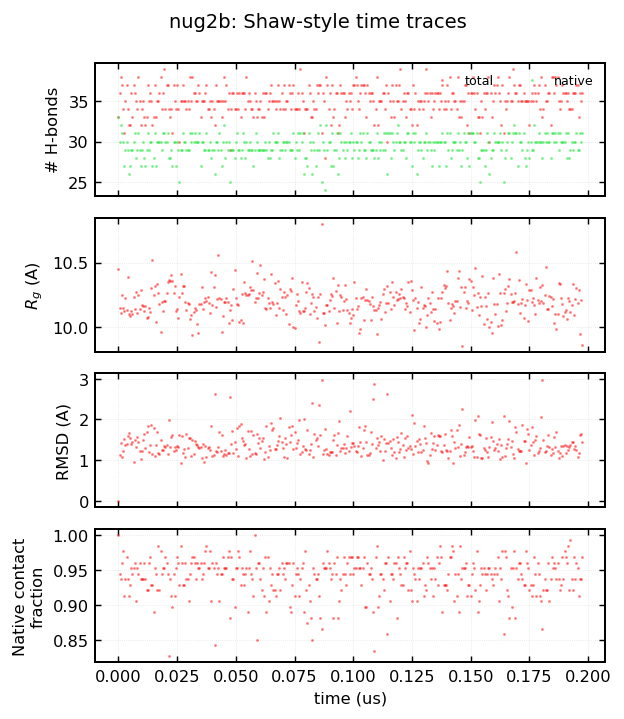

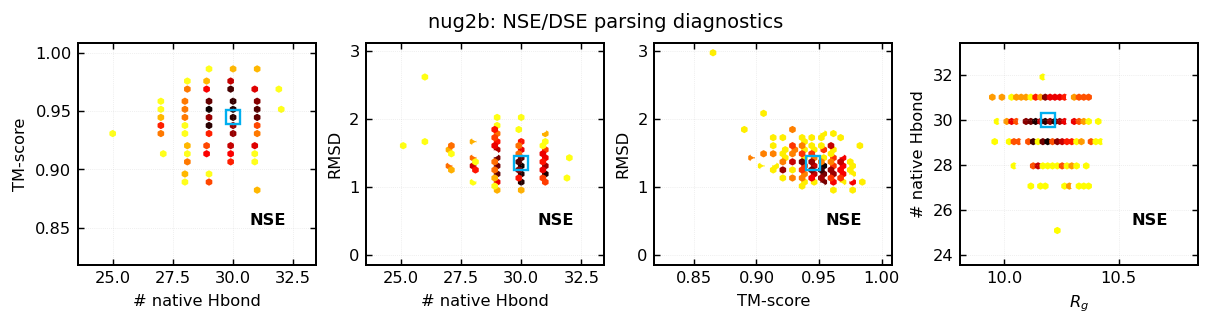

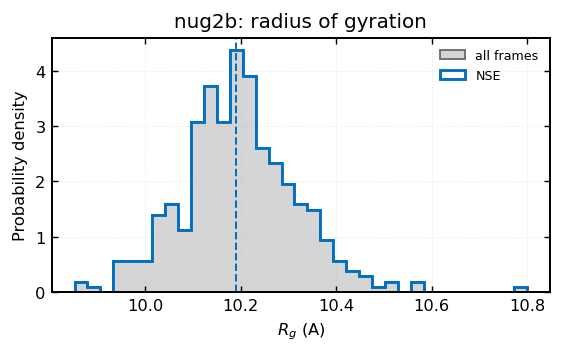

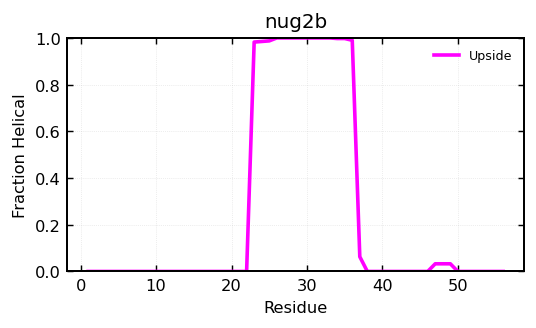

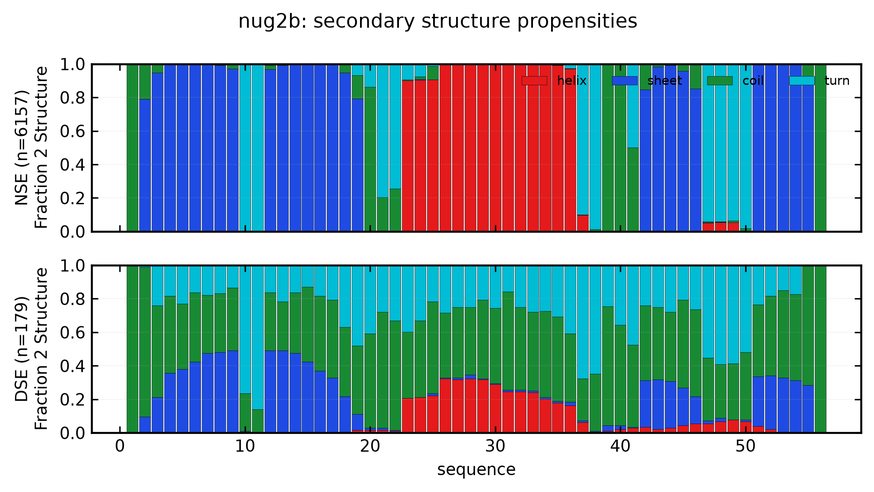

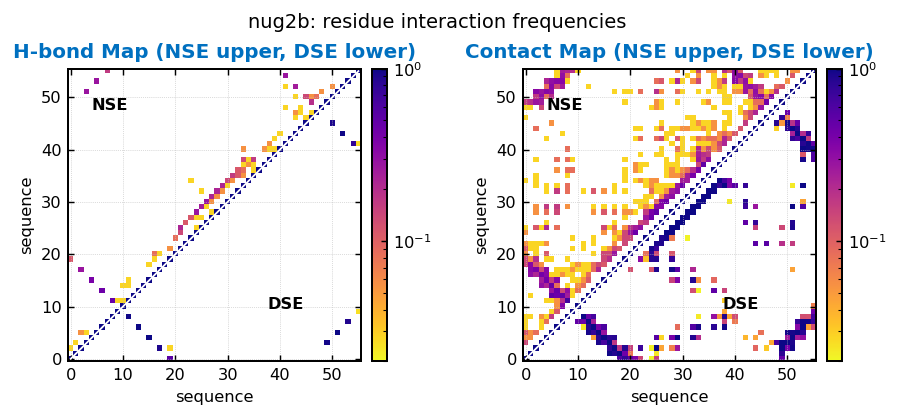

In [6]:
protein = 'nug2b' if 'nug2b' in replica_sets else next(iter(replica_sets))
if HAVE_MDTRAJ_UPSIDE:
    summary = make_all_figures(protein, replica_index=0, stride=5)
else:
    summary = None
    print('Skipping mdtraj_upside-dependent panel set; running HDF5-only requested figures below.')


## Compare all simulations as melting/stability summaries

This panel follows the Fig. 4 visual idea: fraction folded across the replica ladder. The x-axis is Upside reduced temperature, not Kelvin, unless you calibrate the reduced-temperature scale against experimental melting data.

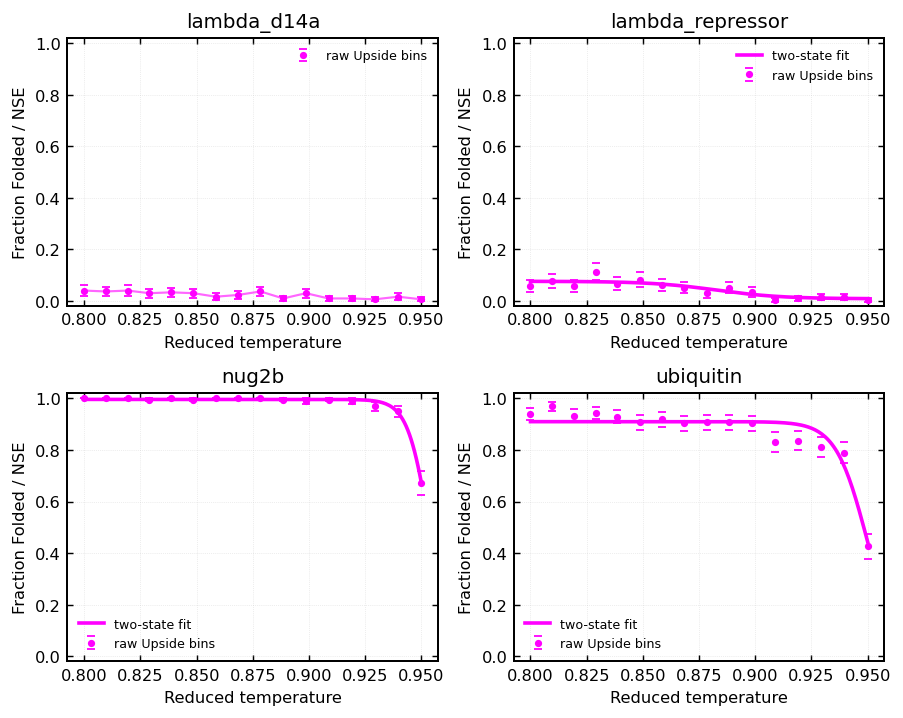

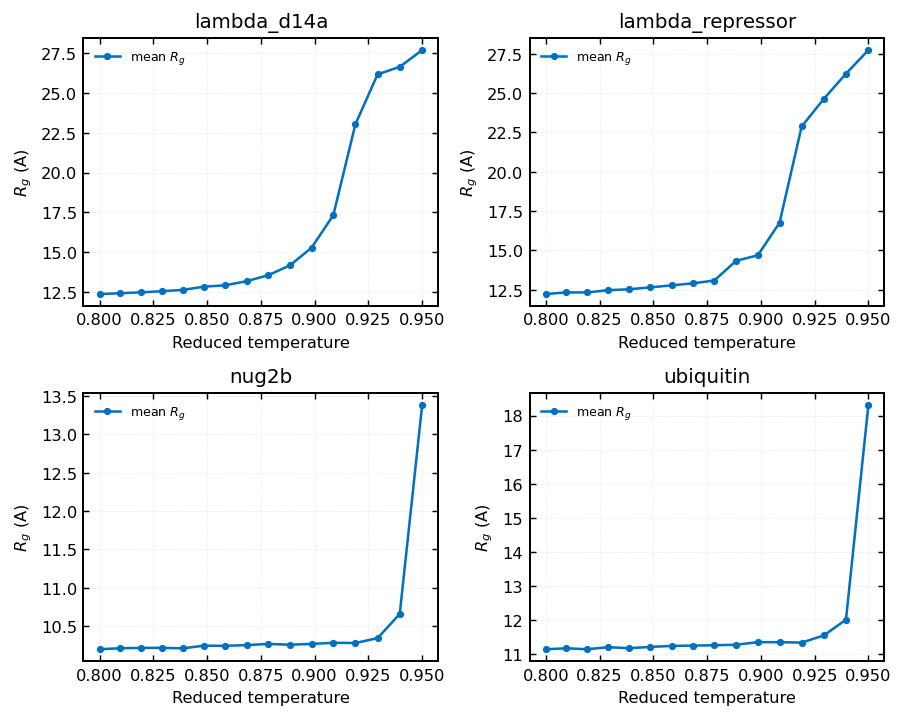

In [7]:
if HAVE_MDTRAJ_UPSIDE:
    plot_melting_summary(stride=10)
    plot_rg_temperature_summary(stride=10)
else:
    print('Skipping mdtraj_upside-dependent melting/Rg summaries; HDF5-only Rg temperature diagnostics are below.')


## Exact Skinner Fig. 1 plus local Rg/swap diagnostics

The first output below is the exact Fig. 1 crop rendered from the bundled Skinner/Yu/Sosnick PNAS PDF. The following plots reproduce that panel grammar from the local Upside `.up` data using only HDF5 arrays, then show framewise Rg across the temperature ladder and Rg behavior while replicas swap through temperature lanes.


In [8]:
import h5py
from IPython.display import Image as IPImage, display

PAPER_FIG1 = FIG_ROOT / 'skinner_fig1_paper_exact.png'
PAPER_FIG1_WITH_CAPTION = FIG_ROOT / 'skinner_fig1_paper_exact_with_caption.png'


def display_paper_skinner_fig1(width: int = 520) -> None:
    if not PAPER_FIG1.exists():
        raise FileNotFoundError(
            f'Missing {PAPER_FIG1}. Render/crop the bundled Skinner PDF before running this display cell.'
        )
    display(IPImage(filename=str(PAPER_FIG1), width=width))


def output_group_names(handle: h5py.File) -> list[str]:
    previous = sorted(
        [name for name in handle.keys() if name.startswith('output_previous_')],
        key=lambda name: int(name.rsplit('_', 1)[1]),
    )
    return previous + (['output'] if 'output' in handle else [])


def read_hdf5_dataset(path: Path, dataset: str, stride: int = 1) -> np.ndarray:
    chunks = []
    with h5py.File(path, 'r', locking=False) as handle:
        for group_index, group_name in enumerate(output_group_names(handle)):
            group = handle[group_name]
            if dataset not in group:
                continue
            raw = np.asarray(group[dataset])
            if group_index > 0 and raw.shape[0] > 1:
                raw = raw[1:]
            chunks.append(raw[::stride])
    if not chunks:
        return np.array([])
    return np.concatenate(chunks, axis=0)


def read_swap_counters(path: Path, stride: int = 1) -> np.ndarray:
    chunks = []
    offset = None
    with h5py.File(path, 'r', locking=False) as handle:
        for group_index, group_name in enumerate(output_group_names(handle)):
            group = handle[group_name]
            if 'replica_cumulative_swaps' not in group:
                continue
            raw = np.asarray(group['replica_cumulative_swaps']).reshape(len(group['replica_cumulative_swaps']), -1).astype(float)
            if group_index > 0 and raw.shape[0] > 1:
                raw = raw[1:]
            if offset is not None and raw.size:
                raw = raw + offset
            if raw.size:
                offset = raw[-1]
            chunks.append(raw[::stride])
    if not chunks:
        return np.empty((0, 0))
    return np.concatenate(chunks, axis=0)


def read_input_positions(path: Path) -> np.ndarray:
    with h5py.File(path, 'r', locking=False) as handle:
        return np.asarray(handle['input/pos']).squeeze().astype(float)


def read_sequence(path: Path) -> list[str]:
    with h5py.File(path, 'r', locking=False) as handle:
        return [item.decode('utf-8') if isinstance(item, bytes) else str(item) for item in handle['input/sequence'][:]]


def read_hbond_pair_indices(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    with h5py.File(path, 'r', locking=False) as handle:
        group = handle['input/potential/protein_hbond']
        donor_res = np.asarray(group['id1'], dtype=int)
        acceptor_res = np.asarray(group['id2'], dtype=int)
        idx1 = np.asarray(group['index1'], dtype=int)
        idx2 = np.asarray(group['index2'], dtype=int)
    return donor_res, acceptor_res, idx1, idx2


def read_positions(path: Path, stride: int = 1) -> np.ndarray:
    pos = read_hdf5_dataset(path, 'pos', stride=stride).astype(float)
    if pos.ndim == 4 and pos.shape[1] == 1:
        pos = pos[:, 0]
    return pos


def rg_from_positions(positions: np.ndarray) -> np.ndarray:
    center = positions.mean(axis=1, keepdims=True)
    return np.sqrt(((positions - center) ** 2).sum(axis=2).mean(axis=1))


def ca_positions(positions: np.ndarray) -> np.ndarray:
    return positions[:, 1::3, :] if positions.ndim == 3 else positions[1::3, :]


def kabsch_rmsd_series(mobile: np.ndarray, reference: np.ndarray) -> np.ndarray:
    ref = reference - reference.mean(axis=0, keepdims=True)
    out = np.empty(mobile.shape[0], dtype=float)
    for index, coords in enumerate(mobile):
        mob = coords - coords.mean(axis=0, keepdims=True)
        cov = mob.T @ ref
        v, _, wt = np.linalg.svd(cov)
        if np.linalg.det(v @ wt) < 0:
            v[:, -1] *= -1
        rot = v @ wt
        aligned = mob @ rot
        out[index] = np.sqrt(((aligned - ref) ** 2).sum(axis=1).mean())
    return out


def native_contact_pairs_from_ca(reference_ca: np.ndarray, min_separation: int = 3, cutoff: float = 8.0) -> np.ndarray:
    pairs = []
    for i in range(len(reference_ca)):
        for j in range(i + min_separation, len(reference_ca)):
            if np.linalg.norm(reference_ca[i] - reference_ca[j]) < cutoff:
                pairs.append((i, j))
    return np.asarray(pairs, dtype=int)


def contact_fraction_series(ca: np.ndarray, pairs: np.ndarray, cutoff: float = 8.0) -> np.ndarray:
    if len(pairs) == 0:
        return np.full(ca.shape[0], np.nan)
    delta = ca[:, pairs[:, 0], :] - ca[:, pairs[:, 1], :]
    distances = np.sqrt((delta ** 2).sum(axis=2))
    return (distances < cutoff).mean(axis=1)


def contact_matrix_by_state(ca: np.ndarray, mask: np.ndarray, cutoff: float = 8.0, min_separation: int = 3) -> np.ndarray:
    selected = ca[mask]
    n_res = ca.shape[1]
    matrix = np.full((n_res, n_res), np.nan)
    if selected.shape[0] == 0:
        return matrix
    for i in range(n_res):
        for j in range(i + min_separation, n_res):
            dist = np.sqrt(((selected[:, i, :] - selected[:, j, :]) ** 2).sum(axis=1))
            matrix[i, j] = matrix[j, i] = np.mean(dist < cutoff)
    return matrix


def hbond_pair_scores(path: Path, stride: int = 1) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    hbond = read_hdf5_dataset(path, 'hbond', stride=stride).astype(float)
    donor_res, acceptor_res, idx1, idx2 = read_hbond_pair_indices(path)
    usable = (idx1 < hbond.shape[1]) & (idx2 < hbond.shape[1])
    pair_scores = 0.5 * (hbond[:, idx1[usable]] + hbond[:, idx2[usable]])
    return pair_scores, donor_res[usable], acceptor_res[usable]


def hbond_state_matrix(pair_scores: np.ndarray, donor_res: np.ndarray, acceptor_res: np.ndarray, mask: np.ndarray, n_res: int) -> np.ndarray:
    matrix = np.full((n_res, n_res), np.nan)
    if pair_scores.shape[0] == 0 or mask.sum() == 0:
        return matrix
    mean_scores = pair_scores[mask].mean(axis=0)
    for score, donor, acceptor in zip(mean_scores, donor_res, acceptor_res):
        if 0 <= donor < n_res and 0 <= acceptor < n_res:
            matrix[donor, acceptor] = score
    return matrix


def combine_state_matrices(nse_matrix: np.ndarray, dse_matrix: np.ndarray) -> np.ndarray:
    n = nse_matrix.shape[0]
    combined = np.full_like(nse_matrix, np.nan, dtype=float)
    upper = np.triu_indices(n, k=1)
    lower = np.tril_indices(n, k=-1)
    combined[upper] = nse_matrix[upper]
    combined[lower] = dse_matrix[lower]
    diag = np.diag_indices(n)
    combined[diag] = 1.0
    return combined


def run_file_for_index(protein: str, run_index: int) -> Path:
    path = SIM_ROOT / protein / 'outputs' / 'remd' / f'{protein}.run.{run_index}.up'
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def available_run_files(protein: str) -> list[Path]:
    remd = SIM_ROOT / protein / 'outputs' / 'remd'
    files = [p for p in remd.glob(f'{protein}.run.*.up') if _valid_up_file(p)]
    return sorted(files, key=_sort_key)


def hdf5_observables(protein: str, run_index: int = 0, stride: int = 1) -> dict[str, object]:
    path = run_file_for_index(protein, run_index)
    positions = read_positions(path, stride=stride)
    reference = read_input_positions(path)
    sequence = read_sequence(path)
    tag_len = n_terminal_tag_length(protein, sequence)
    if tag_len:
        positions = positions[:, tag_len * 3:, :]
        reference = reference[tag_len * 3:, :]
        sequence = sequence[tag_len:]
    ca = ca_positions(positions)
    reference_ca = reference[1::3, :]
    pair_scores, donor_res, acceptor_res = hbond_pair_scores(path, stride=stride)
    if tag_len:
        keep_pairs = (donor_res >= tag_len) & (acceptor_res >= tag_len)
        pair_scores = pair_scores[:, keep_pairs]
        donor_res = donor_res[keep_pairs] - tag_len
        acceptor_res = acceptor_res[keep_pairs] - tag_len
    hbond_sites = (pair_scores > 0.5).sum(axis=1)
    hbond_score = pair_scores.sum(axis=1)
    q_native = contact_fraction_series(ca, native_contact_pairs_from_ca(reference_ca))
    rmsd = kabsch_rmsd_series(ca, reference_ca)
    rg = rg_from_positions(positions)
    temperature = read_hdf5_dataset(path, 'temperature', stride=stride).reshape(-1).astype(float)
    replica_index = read_hdf5_dataset(path, 'replica_index', stride=stride).reshape(-1).astype(float)
    swaps = read_swap_counters(path, stride=stride)
    if not swaps.size:
        swaps = np.empty((len(rg), 0))
    n = min(len(rg), len(temperature), len(replica_index), pair_scores.shape[0], len(q_native), len(rmsd), swaps.shape[0] if swaps.size else len(rg))
    rg = rg[:n]
    rmsd = rmsd[:n]
    q_native = q_native[:n]
    hbond_sites = hbond_sites[:n]
    hbond_score = hbond_score[:n]
    pair_scores = pair_scores[:n]
    temperature = temperature[:n]
    replica_index = replica_index[:n]
    swaps = swaps[:n] if swaps.size else swaps
    nse = (rmsd < SKINNER_STATE.rmsd_cutoff_angstrom) & (q_native > SKINNER_STATE.q_native_cutoff) & (hbond_sites > SKINNER_STATE.native_hbond_cutoff)
    dse = ~nse
    return {
        'protein': protein,
        'path': path,
        'run_index': run_index,
        'frame': np.arange(n),
        'time_us': np.arange(n) * stride * 100.0 / 1_000_000.0,
        'rg': rg,
        'rmsd': rmsd,
        'q_native': q_native,
        'hbond_sites': hbond_sites,
        'hbond_score': hbond_score,
        'pair_scores': pair_scores,
        'donor_res': donor_res,
        'acceptor_res': acceptor_res,
        'temperature': temperature,
        'replica_index': replica_index,
        'swaps': swaps,
        'ca': ca[:n],
        'states': {'NSE': nse, 'DSE': dse},
        'sequence': sequence,
    }


def hdf5_ensemble_observables(protein: str, stride: int = 1) -> dict[str, object]:
    items = [hdf5_observables(protein, run_index=i, stride=stride) for i, _ in enumerate(available_run_files(protein))]
    first = items[0]
    concat_keys = ['rg', 'rmsd', 'q_native', 'hbond_sites', 'hbond_score', 'pair_scores', 'temperature', 'replica_index', 'ca']
    data = {key: np.concatenate([item[key] for item in items], axis=0) for key in concat_keys}
    n = len(data['rg'])
    nse = (data['rmsd'] < SKINNER_STATE.rmsd_cutoff_angstrom) & (data['q_native'] > SKINNER_STATE.q_native_cutoff) & (data['hbond_sites'] > SKINNER_STATE.native_hbond_cutoff)
    data.update({
        'protein': protein,
        'path': Path(f'{protein}: {len(items)} HDF5 run files'),
        'run_index': None,
        'frame': np.arange(n),
        'time_us': np.arange(n) * stride * 100.0 / 1_000_000.0,
        'donor_res': first['donor_res'],
        'acceptor_res': first['acceptor_res'],
        'swaps': np.empty((n, 0)),
        'states': {'NSE': nse, 'DSE': ~nse},
        'sequence': first['sequence'],
    })
    return data


SKINNER_NUG2B_HX_TABLE = [
    {'residue': 3, 'aa': 'Y', 'delta_g_hx': 8.08, 'se': 0.11},
    {'residue': 4, 'aa': 'K', 'delta_g_hx': 8.54, 'se': 0.11},
    {'residue': 5, 'aa': 'L', 'delta_g_hx': 8.31, 'se': 0.11},
    {'residue': 6, 'aa': 'V', 'delta_g_hx': 8.09, 'se': 0.11},
    {'residue': 7, 'aa': 'I', 'delta_g_hx': 7.84, 'se': 0.11},
    {'residue': 16, 'aa': 'Y', 'delta_g_hx': 7.85, 'se': 0.14},
    {'residue': 18, 'aa': 'T', 'delta_g_hx': 7.85, 'se': 0.17},
    {'residue': 26, 'aa': 'A', 'delta_g_hx': 8.45, 'se': 0.15},
    {'residue': 27, 'aa': 'E', 'delta_g_hx': 7.74, 'se': 0.12},
    {'residue': 30, 'aa': 'F', 'delta_g_hx': 7.93, 'se': 0.12},
    {'residue': 31, 'aa': 'K', 'delta_g_hx': 7.94, 'se': 0.14},
    {'residue': 51, 'aa': 'T', 'delta_g_hx': 8.30, 'se': 0.12},
]
SKINNER_NUG2B_GLOBALS = {
    'CD': {'delta_g': 7.48, 'se': 0.23},
    'kinetics': {'delta_g': 7.78, 'se': 0.23},
    'm_hx': {'value': 1.29, 'se': 0.10},
}
KCAL_PER_MOL_K = 0.00198720425864083


def read_upside_hdx_csv(protein: str = 'nug2b') -> list[dict[str, object]]:
    path = REPO / 'docs' / 'data' / f'{protein}_upside_hdx.csv'
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Generate it with scripts/upside_hdx_nug2b.py so this plot uses '
            'Upside protection-state + MBAR HDX logic rather than the older hbond-only proxy.'
        )
    import csv
    rows = []
    with path.open(newline='', encoding='utf-8') as handle:
        for row in csv.DictReader(handle):
            parsed = {'residue': int(row['residue']), 'skinner_aa': row['skinner_aa']}
            for key in ['upside_delta_g_hx', 'upside_m_value', 'skinner_delta_g_hx', 'skinner_se']:
                parsed[key] = float(row[key]) if row[key] else np.nan
            rows.append(parsed)
    return rows


def plot_nug2b_delta_g_hx_overlay(protein: str = 'nug2b', save: bool = True) -> plt.Figure:
    if protein != 'nug2b':
        raise ValueError('Skinner Table S1 HDX values are currently encoded only for NuG2b.')
    rows = [row for row in read_upside_hdx_csv(protein) if np.isfinite(row['skinner_delta_g_hx'])]
    rows = sorted(rows, key=lambda row: row['residue'])
    residues = np.array([row['residue'] for row in rows], dtype=int)
    labels = [f"{row['residue']}{row['skinner_aa']}" for row in rows]
    exp_y = np.array([row['skinner_delta_g_hx'] for row in rows], dtype=float)
    exp_se = np.array([row['skinner_se'] for row in rows], dtype=float)
    sim_y = np.array([row['upside_delta_g_hx'] for row in rows], dtype=float)

    fig, ax = plt.subplots(figsize=(7.4, 3.7), constrained_layout=True)
    ax.errorbar(
        residues,
        exp_y,
        yerr=exp_se,
        fmt='s',
        ms=4.5,
        color='black',
        ecolor='0.35',
        elinewidth=0.8,
        capsize=2,
        label='Skinner experiment (Table S1)',
    )
    ax.plot(
        residues,
        sim_y,
        'o-',
        ms=4.2,
        lw=1.4,
        color='#d95f02',
        label='Upside HDX PS + MBAR',
    )
    ax.axhline(SKINNER_NUG2B_GLOBALS['CD']['delta_g'], color='#0072b2', ls='--', lw=1.0, label='Skinner CD global')
    ax.axhline(SKINNER_NUG2B_GLOBALS['kinetics']['delta_g'], color='#009e73', ls=':', lw=1.3, label='Skinner kinetic global')
    ax.set_xticks(residues)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel(r'$\Delta G_{HX}$ (kcal/mol)')
    ax.set_xlabel('NuG2b residue')
    ax.set_title('NuG2b HDX stability: Skinner experiment vs Upside HDX workflow')
    ax.grid(axis='y', ls=':', lw=0.4, alpha=0.45)
    ax.legend(frameon=False, loc='best')
    ax.text(
        0.01,
        0.03,
        'Upside values from get_protection_state.py protection states and MBAR reweighting',
        transform=ax.transAxes,
        fontsize=7,
        color='0.28',
        va='bottom',
    )
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_upside_hdx_delta_g_overlay.png', bbox_inches='tight')
    return fig


def plot_hdf5_skinner_fig1_reproduction(protein: str = 'nug2b', run_index: int | None = None, stride: int = 1, save: bool = True) -> plt.Figure:
    data = hdf5_ensemble_observables(protein, stride=stride) if run_index is None else hdf5_observables(protein, run_index=run_index, stride=stride)
    nse = data['states']['NSE']
    dse = data['states']['DSE']
    n_res = len(data['sequence'])
    fig = plt.figure(figsize=(9.4, 8.4))
    gs = fig.add_gridspec(
        5,
        4,
        width_ratios=[3.0, 0.78, 2.45, 2.45],
        height_ratios=[1, 1, 1, 1, 2.15],
        wspace=0.55,
        hspace=0.72,
    )

    trace_specs = [
        ('hbond_sites', '# protected H-bond sites', '#2aa84a'),
        ('rg', '$R_g$ (A)', '#e41a1c'),
        ('rmsd', 'C-alpha RMSD (A)', '#e41a1c'),
        ('q_native', 'native-contact score', '#e41a1c'),
    ]
    first_trace_ax = None
    for row, (key, ylabel, color) in enumerate(trace_specs):
        ax = fig.add_subplot(gs[row, 0])
        hist_ax = fig.add_subplot(gs[row, 1], sharey=ax)
        if first_trace_ax is None:
            first_trace_ax = ax
        ax.plot(data['time_us'], data[key], '.', ms=1.0, color=color, alpha=0.55)
        if np.any(dse):
            lo, hi = np.nanpercentile(data[key][dse], [5, 95])
            ax.axhspan(lo, hi, color='0.9', alpha=0.28, lw=0)
        ax.set_ylabel(ylabel)
        ax.grid(ls=':', lw=0.35, alpha=0.4)
        hist_values = data[key][dse] if np.any(dse) else data[key]
        hist_ax.hist(hist_values, bins=32, orientation='horizontal', color=color, alpha=0.25, density=True)
        hist_ax.set_xticks([])
        hist_ax.tick_params(labelleft=False)
        hist_ax.grid(ls=':', lw=0.35, alpha=0.25)
        if row < 3:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('time (us)')
    first_trace_ax.text(-0.25, 1.02, 'A', transform=first_trace_ax.transAxes, fontsize=15, fontweight='bold', va='top')

    profile_axes = [fig.add_subplot(gs[0:2, 2:4]), fig.add_subplot(gs[2:4, 2:4])]
    residues = np.arange(1, n_res + 1)
    donor = data['donor_res']
    for ax, mask, label in zip(profile_axes, [nse, dse], ['NSE', 'DSE']):
        if mask.sum() == 0:
            mean_by_pair = np.zeros_like(donor, dtype=float)
        else:
            mean_by_pair = data['pair_scores'][mask].mean(axis=0)
        per_res = np.zeros(n_res, dtype=float)
        counts = np.zeros(n_res, dtype=float)
        for resid, score in zip(donor, mean_by_pair):
            if 0 <= resid < n_res:
                per_res[resid] += score
                counts[resid] += 1
        per_res = np.divide(per_res, counts, out=np.zeros_like(per_res), where=counts > 0)
        ax.bar(residues, per_res, width=0.85, color='#00bcd4', edgecolor='black', linewidth=0.15)
        ax.set_ylim(0, 1)
        ax.set_ylabel('H-bond score')
        ax.set_title(f'{label}: donor-residue protection proxy', pad=6)
        ax.grid(axis='y', ls=':', lw=0.35, alpha=0.4)
    profile_axes[0].text(-0.075, 0.98, 'B', transform=profile_axes[0].transAxes, fontsize=15, fontweight='bold', va='top')
    profile_axes[-1].set_xlabel('sequence')

    hbond_nse = hbond_state_matrix(data['pair_scores'], data['donor_res'], data['acceptor_res'], nse, n_res)
    hbond_dse = hbond_state_matrix(data['pair_scores'], data['donor_res'], data['acceptor_res'], dse, n_res)
    contact_nse = contact_matrix_by_state(data['ca'], nse)
    contact_dse = contact_matrix_by_state(data['ca'], dse)
    map_specs = [
        (combine_state_matrices(hbond_nse, hbond_dse), 'H-bond proxy map'),
        (combine_state_matrices(contact_nse, contact_dse), 'Contact map'),
    ]
    map_axes = []
    for col, (matrix, title) in enumerate(map_specs):
        ax = fig.add_subplot(gs[4, col * 2:(col + 1) * 2])
        map_axes.append(ax)
        masked = np.ma.masked_invalid(matrix)
        im = ax.imshow(masked, origin='lower', vmin=0, vmax=1, cmap='plasma_r', interpolation='nearest')
        ax.plot([0, n_res - 1], [0, n_res - 1], color='white', lw=1.0)
        ax.text(0.10, 0.78, 'NSE', transform=ax.transAxes, fontsize=10, fontweight='bold')
        ax.text(0.58, 0.20, 'DSE', transform=ax.transAxes, fontsize=10, fontweight='bold')
        ax.set_title(title, color='#0070c0', fontweight='bold', pad=6)
        ax.set_xlabel('sequence')
        ax.set_ylabel('sequence')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    map_axes[0].text(0.03, 0.97, 'D', transform=map_axes[0].transAxes, fontsize=15, fontweight='bold', va='top')

    source_label = 'ensemble' if run_index is None else f'run {run_index}'
    fig.suptitle(f'{protein}: local Upside HDF5 {source_label} reproduction of Skinner Fig. 1 grammar', y=0.99)
    fig.subplots_adjust(top=0.91, bottom=0.07, left=0.08, right=0.97)
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_skinner_fig1_hdf5_reproduction.png', bbox_inches='tight')
    return fig


def plot_rg_frame_temperature_ladder(protein: str = 'nug2b', stride: int = 2, save: bool = True) -> plt.Figure:
    files = available_run_files(protein)
    n = len(files)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.2, 1.75 * nrows), sharex=True, sharey=True, squeeze=False)
    for ax, path in zip(axes.ravel(), files):
        positions = read_positions(path, stride=stride)
        rg = rg_from_positions(positions)
        temp = read_hdf5_dataset(path, 'temperature', stride=stride).reshape(-1)
        frames = np.arange(min(len(rg), len(temp))) * stride
        rg = rg[:len(frames)]
        temp = temp[:len(frames)]
        ax.plot(frames, rg, color='#0070c0', lw=0.75, alpha=0.9)
        ax.set_title(f'T={np.nanmedian(temp):.4f}', fontsize=8)
        ax.grid(ls=':', lw=0.3, alpha=0.35)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    for ax in axes[-1, :]:
        ax.set_xlabel('frame')
    for ax in axes[:, 0]:
        ax.set_ylabel('$R_g$ (A)')
    fig.suptitle(f'{protein}: framewise $R_g$ over the temperature ladder', y=1.01)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_rg_frame_temperature_ladder.png', bbox_inches='tight')
    return fig


def plot_rg_swap_heatmap(protein: str = 'nug2b', stride: int = 2, save: bool = True) -> plt.Figure:
    files = available_run_files(protein)
    rows = []
    labels = []
    max_len = 0
    for path in files:
        positions = read_positions(path, stride=stride)
        rg = rg_from_positions(positions)
        temp = read_hdf5_dataset(path, 'temperature', stride=stride).reshape(-1)
        n = min(len(rg), len(temp))
        rows.append(rg[:n])
        labels.append(float(np.nanmedian(temp[:n])))
        max_len = max(max_len, n)
    matrix = np.full((len(rows), max_len), np.nan)
    for index, row in enumerate(rows):
        matrix[index, :len(row)] = row
    fig, ax = plt.subplots(figsize=(8.4, 3.7))
    im = ax.imshow(matrix, aspect='auto', interpolation='nearest', origin='lower', cmap='viridis')
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels([f'{label:.4f}' for label in labels], fontsize=7)
    ax.set_xlabel(f'frame / {stride}')
    ax.set_ylabel('temperature lane')
    ax.set_title(f'{protein}: $R_g$ by temperature lane during replica exchange')
    fig.colorbar(im, ax=ax, label='$R_g$ (A)')
    fig.tight_layout()
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_rg_swap_heatmap.png', bbox_inches='tight')
    return fig


def plot_rg_swap_diagnostics(protein: str = 'nug2b', run_index: int = 15, stride: int = 1, save: bool = True) -> plt.Figure:
    data = hdf5_observables(protein, run_index=run_index, stride=stride)
    frame = data['frame'] * stride
    fig, axes = plt.subplots(3, 1, figsize=(7.6, 5.6), sharex=True, constrained_layout=True)
    sc = axes[0].scatter(frame, data['rg'], c=data['replica_index'], s=4, cmap='turbo', alpha=0.75)
    axes[0].plot(frame, moving_average(data['rg'], 21), color='black', lw=0.75, alpha=0.65)
    axes[0].set_ylabel('$R_g$ (A)')
    axes[0].set_title(f'{protein} run.{run_index}: $R_g$ colored by swapped replica index')
    fig.colorbar(sc, ax=axes[0], label='replica index')
    axes[1].plot(frame, data['replica_index'], color='#6a3d9a', lw=0.7)
    axes[1].set_ylabel('replica index')
    axes[2].set_ylabel('cumulative swaps')
    if data['swaps'].size:
        for col in range(min(2, data['swaps'].shape[1])):
            label = 'counter 0' if col == 0 else 'counter 1'
            axes[2].plot(frame, data['swaps'][:, col], lw=0.9, label=label)
        axes[2].legend(frameon=False, ncol=2, loc='upper left')
    axes[2].set_xlabel('frame')
    for ax in axes:
        ax.grid(ls=':', lw=0.35, alpha=0.4)
    if save:
        fig.savefig(FIG_ROOT / f'{protein}_rg_swap_diagnostics.png', bbox_inches='tight')
    return fig


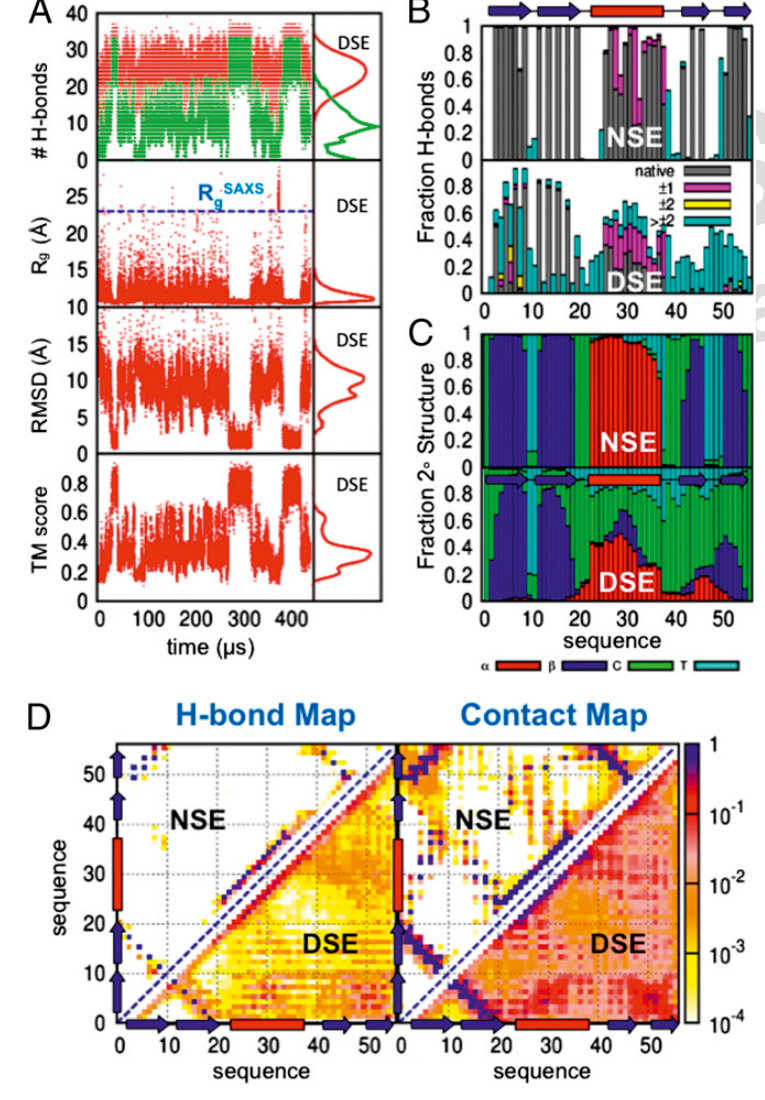

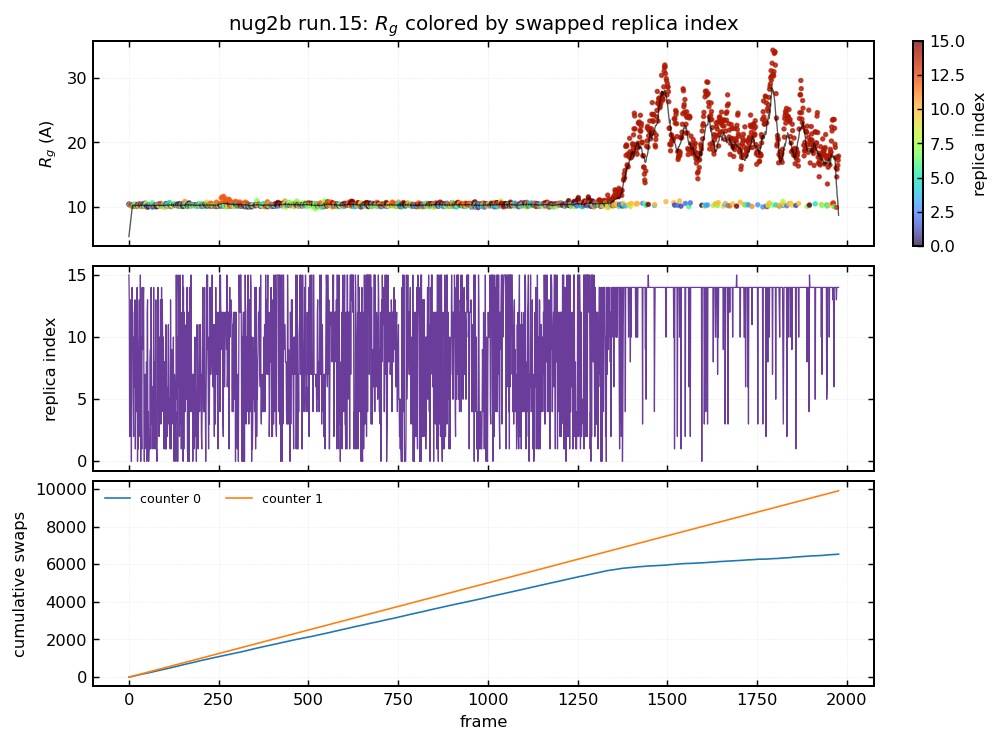

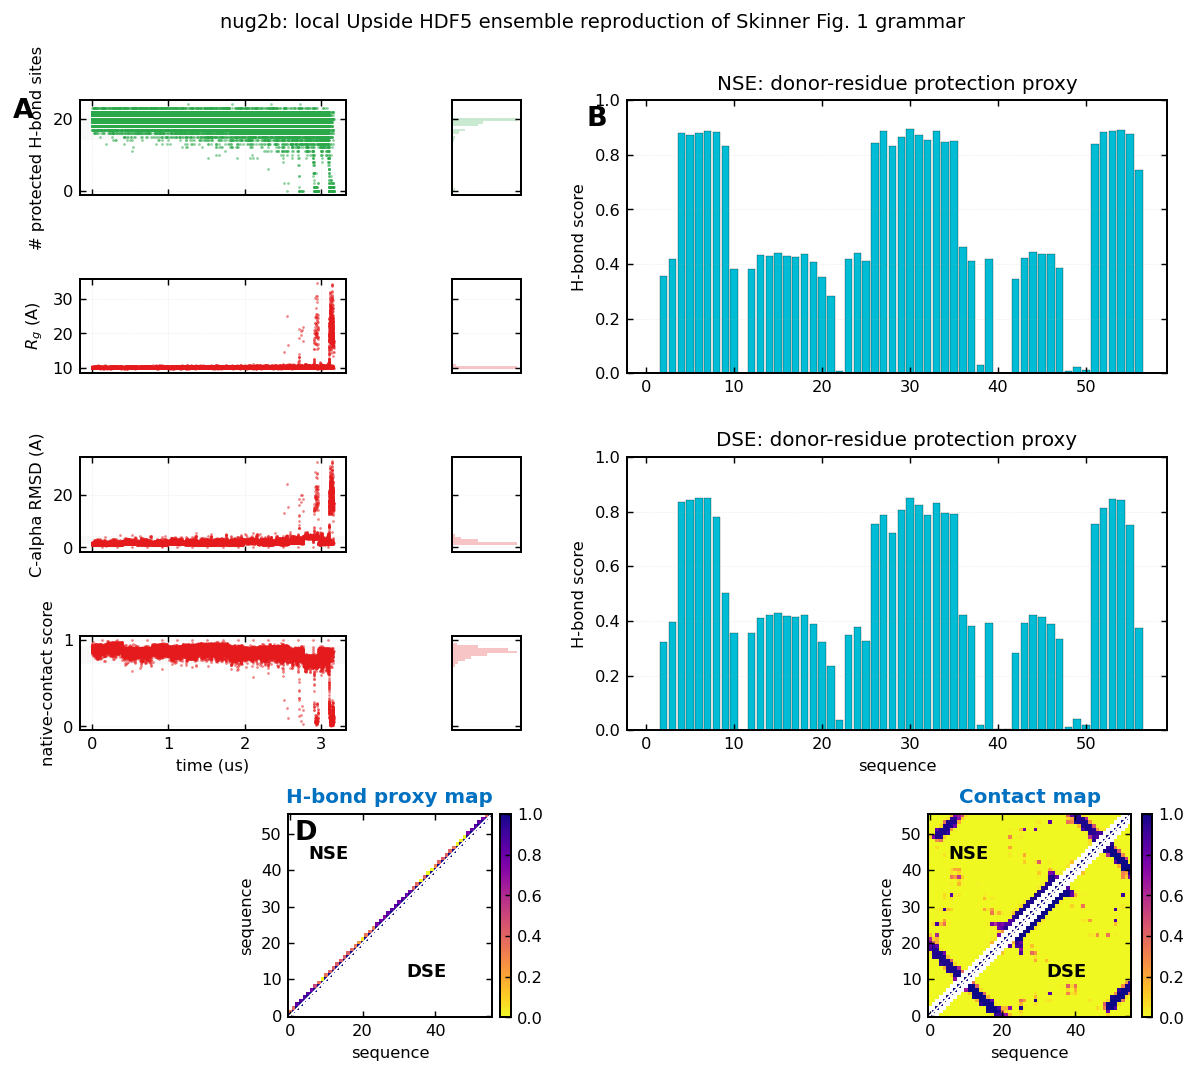

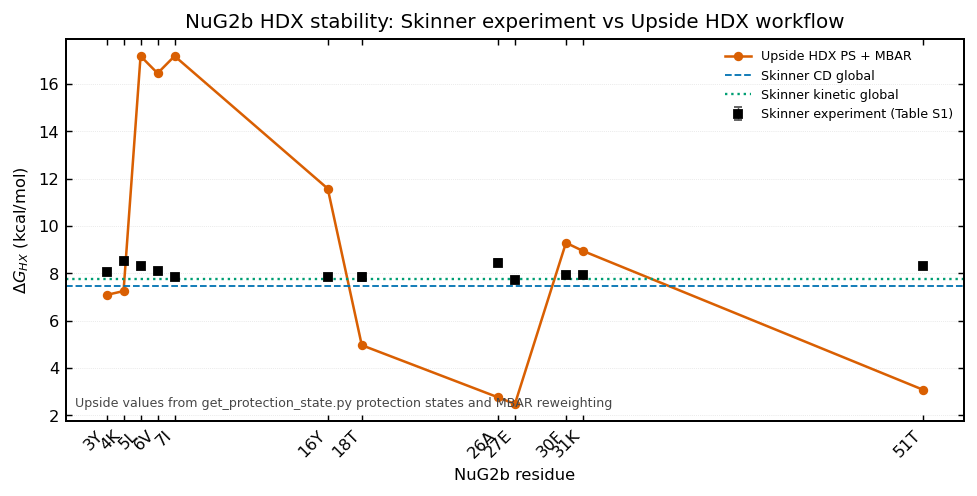

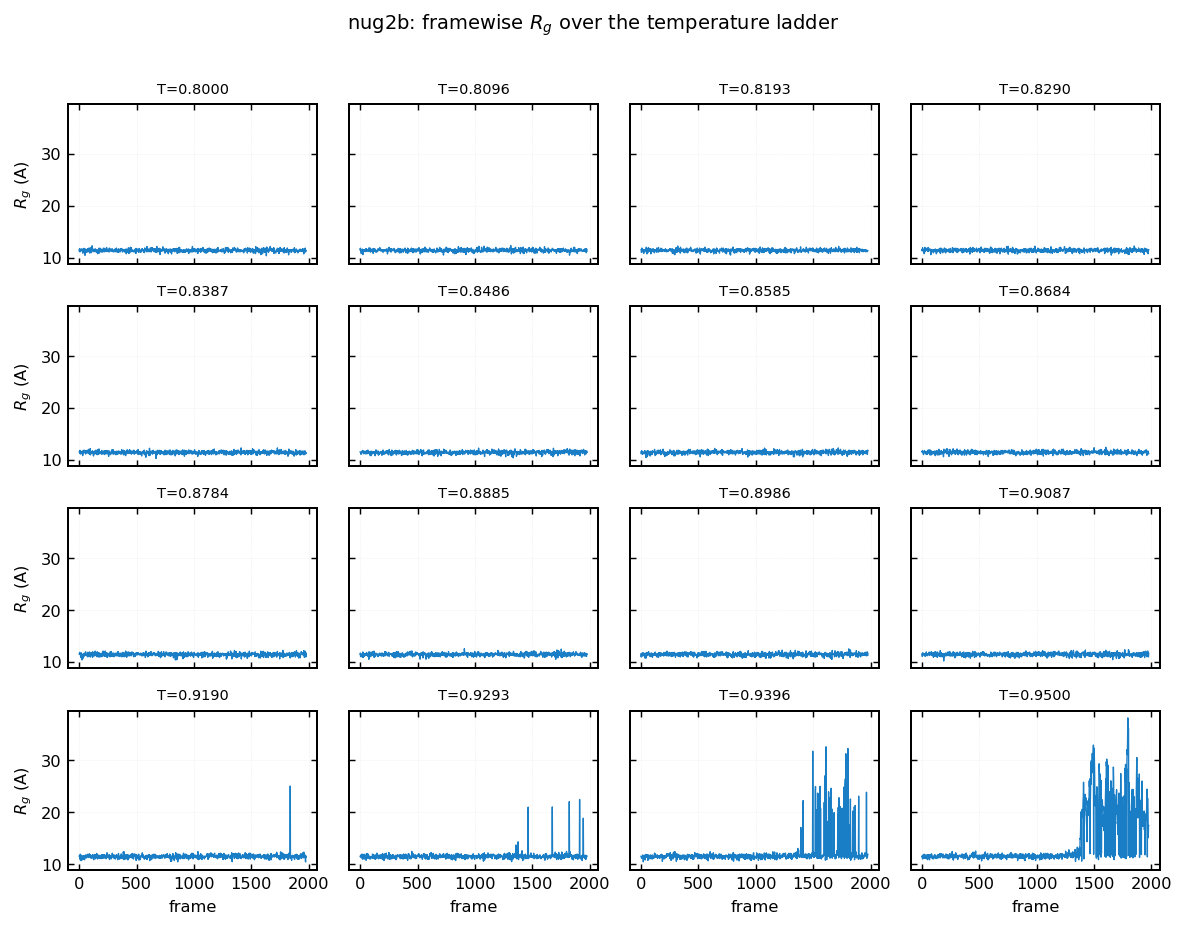

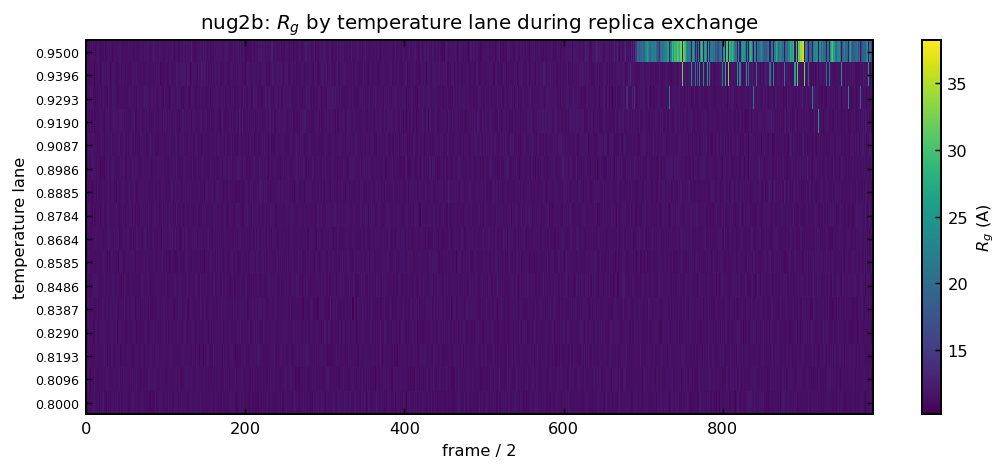

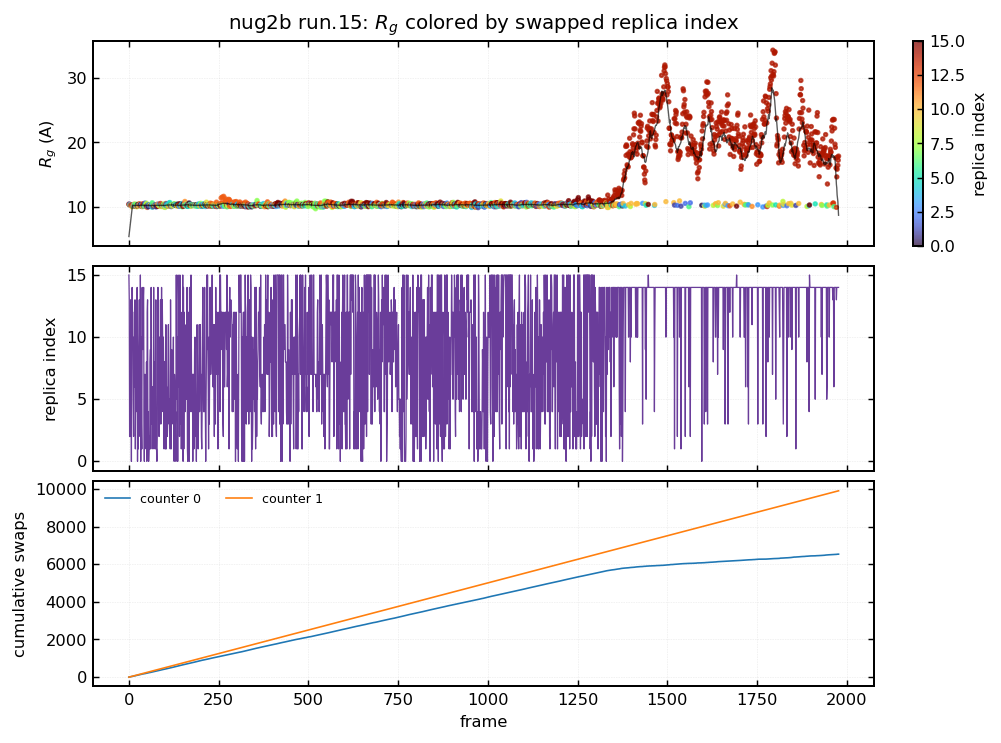

In [9]:
display_paper_skinner_fig1(width=520)
plot_hdf5_skinner_fig1_reproduction('nug2b', run_index=None, stride=1)
plot_nug2b_delta_g_hx_overlay('nug2b')
plot_rg_frame_temperature_ladder('nug2b', stride=2)
plot_rg_swap_heatmap('nug2b', stride=2)
plot_rg_swap_diagnostics('nug2b', run_index=15, stride=1)


## Notes for extending toward exact paper panels

- Skinner et al. define NuG2b `NSEsim` using fixed cutoffs: C-alpha RMSD below 4 A, native H-bonds above 20, and TM score above 0.6; all other conformations are `DSEsim`. This notebook uses that fixed-rule logic, with native-contact fraction as the available TM-like surrogate.
- Shaw/Robustelli Fig. 4 used simulated tempering ladders in Kelvin and plotted system-specific folded/helix observables. Our Upside x-axis is reduced temperature until calibrated, and REMD demultiplexing/MBAR should be added before treating the curve as a publication thermodynamic melting curve.
- Skinner's NuG2b Table S1 HDX stabilities are encoded in this notebook and overlaid against `docs/data/nug2b_upside_hdx.csv`, generated by `scripts/upside_hdx_nug2b.py` from Upside protection states plus MBAR. Raw time-resolved NMR exchange intensities are still not bundled.
- `mdtraj.compute_dssp` requires a trajectory topology with atoms sufficient for DSSP assignment. Upside's `mdtraj_upside` loader adds H/O/CB atoms, which is why this notebook routes through it rather than trying to parse HDF5 arrays directly.
- The exact Skinner Fig. 1 crop is saved as `docs/figures/skinner_fig1_paper_exact.png`; the local HDF5 reproduction is saved as `docs/figures/nug2b_skinner_fig1_hdf5_reproduction.png`.
- The framewise Rg and swap diagnostics are saved as `docs/figures/nug2b_rg_frame_temperature_ladder.png`, `docs/figures/nug2b_rg_swap_heatmap.png`, and `docs/figures/nug2b_rg_swap_diagnostics.png`.
